# Variant regulatory consequence analysis

This notebook introduces regulatory regions dataset which contains the regulatory consequences for variants.

The output of this notebook are 3 datasets:

- consequence_dataset with exploded variant consequences per variant, geneId and study type
- consequence_percentages - contains the percentage of variant consequence occurrence across study type
- mean_absolute_effect_by_consequence - contains the mean absolute effect over variant consequence and gwas study type


## Setup

The data requires 3 datasets:

- `RegulatoryRegions` dataset, which contains the regulatory consequences for variants.
- `LeadVariantEffect` dataset, which contains the lead variants and their effects. - use qualified replicated maf filtered dataset.
- `TargetIndex` dataset, which contains the target genes and their TSS positions.

The analysis adds the requlatory consequence information (promoter, enhancer labels) to the lead variants.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import plotnine as p9
from gentropy.assets.variant_consequences import VariantConsequence
from gentropy.common.session import Session
from great_tables import GT
from pyspark.sql import Column, Window
from pyspark.sql import functions as f
from pyspark.sql import types as t

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.consequence import ConsequenceCategory
from manuscript_methods.datasets import LeadVariantEffect
from manuscript_methods.study_statistics import StudyType
from manuscript_methods.ve import SingleVariantEffectMethod, VariantEffect

Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 16:45:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
session.spark

In [7]:
# Inputs

path_to_intermediate_data_folder = "../../../data/intermediate_files/"
path_to_release = "../../../data/25.06/output/"

regulatory_regions_dataset_path = path_to_intermediate_data_folder + "regulatoryToGene"
lead_variant_maf = path_to_intermediate_data_folder + "qualified_lead_variant_effect"
REGULATORY_REGION_SCORE_CUTOFF = 0.05
PAV_THRESHOLD = 0.66
target_index_path = path_to_release + "target"


# Outputs
consequence_dataset_path = path_to_intermediate_data_folder + "lead_variant_consequence_exploded"
consequence_per_study_type = path_to_intermediate_data_folder + "figure_2_c.csv"
mean_absolute_effect_by_consequence_path = path_to_intermediate_data_folder + "figure_2_d.csv"

## Data Loading


In [8]:
lve = LeadVariantEffect.from_parquet(session=session, path=lead_variant_maf)
print(f"Lead variant effect dataset - {lve.df.count():,}")
so_terms_dict = VariantConsequence.map_sequence_ontology()
regulatory_regions_dataset = session.spark.read.parquet(regulatory_regions_dataset_path)
print(f"Regulatory regions dataset - {regulatory_regions_dataset.count():,}")
target_index = session.spark.read.parquet(target_index_path)
print(f"Target index dataset - {target_index.count():,}")

Lead variant effect dataset - 459,516
Regulatory regions dataset - 251,777,418
Target index dataset - 78,726


## Consequence classification

We classify the consequences into 5 categories with the following priority:

1. protein_altering (based on VEP annotation)
2. intragenic (based on VEP annotation)
3. promoter (PROMOTER based on regulatory annotation)
4. enhancer (ENHANCER based on regulatory annotation)
5. intergenic (based on VEP annotation)

The full description of the Sequence Ontology terms used for in the classification is found in `src/manuscript_methods/consequences.py`


In [9]:
so_terms = pd.DataFrame([(d, i) for d, i in so_terms_dict.items()], columns=["term", "featureId"])
so_terms.head()


def map_so_terms(so_term_col: Column, so_terms: pd.DataFrame) -> Column:
    """Map Sequence Ontology (SO) terms to their ids without joining."""
    expr = f.when(f.lit(False), None)
    so_terms = so_terms[["featureId", "term"]]
    for v in so_terms.iterrows():
        so_term = v[1][1]
        so_id = v[1][0]
        expr = expr.when(so_term_col == f.lit(so_id), f.lit(so_term))

    return expr

In [10]:
# Test map_so_terms
test_df = (
    session.spark.createDataFrame(
        [("SO_0001583",), ("SO_0001627",), ("SO_0000001",), (None,)],
        schema=t.StructType([t.StructField("so_id", t.StringType(), True)]),
    )
    .select(
        "so_id",
        map_so_terms(f.col("so_id"), so_terms).alias("so_term"),
    )
    .show(truncate=False)
)

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_58716/1587553865.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



+----------+----------------+
|so_id     |so_term         |
+----------+----------------+
|SO_0001583|missense_variant|
|SO_0001627|intron_variant  |
|SO_0000001|NULL            |
|NULL      |NULL            |
+----------+----------------+



## Preparing regulatory regions dataset for joining

The regulatory regions dataset is:

1. filtered based on a score cutoff to retain high-confidence regulatory scores.
2. deduplicated to ensure we leave only unique geneId-region pairs.
3. We do not control over the tissue-specificity in this analysis.

The Regulatory region is defined as
| chromosome | start | end | intervalType |
|------------|---------|---------|----------------|
| chr1 | 128717 | 129517 | promoter |
| chr1 | 138675 | 139325 | enhancer |
| chr1 | 96475 | 96925 | enhancer |
| chr1 | 103950 | 104600 | enhancer |

Where the `intervalType` can be `promoter` or `enhancer`

<div class="alert alert-block alert-info"> 
<b> region offset </b>
<br>
    Regulatory regions are 0-based (based on bed regions), while the `LeadVariantEffect` dataset is 1-based. This means that we need to add 1 to the start and end positions of the regulatory regions when merging with the 
    `LeadVariantEffect` dataset.
<br>
<br>
<img src="../../../playground/in_silico_effect_prediction/plots/0_vs_1_based.png" width="500"/>
</div>


### Prefiltering


In [11]:
regulatory_regions_filtered = regulatory_regions_dataset.filter(f.col("score") >= REGULATORY_REGION_SCORE_CUTOFF)
print(
    f"Filtered Regulatory regions dataset contains {regulatory_regions_filtered.count():,} records with score >= {REGULATORY_REGION_SCORE_CUTOFF}."
)
unique_regulatory_regions = regulatory_regions_filtered.dropDuplicates(
    ["chromosome", "start", "end", "intervalType", "geneId"]
).select(
    f.regexp_replace(f.col("chromosome"), "chr", "").alias("chromosome"),
    (f.col("start") + 1).alias("start"),
    (f.col("end") + 1).alias("end"),
    "intervalType",
    "geneId",
)
print(f"Unique regulatory regions dataset contains {unique_regulatory_regions.count():,} records.")
GT(unique_regulatory_regions.limit(10).toPandas()).tab_header("Unique regulatory regions sample")

Filtered Regulatory regions dataset contains 4,066,081 records with score >= 0.05.


Unique regulatory regions dataset contains 569,842 records.


GT(_tbl_data=  chromosome       start         end intervalType           geneId
0          1   6785155.0   6785955.0     promoter  ENSG00000171735
1          1  10377351.0  10377801.0     enhancer  ENSG00000142655
2          1  11790701.0  11791276.0     enhancer  ENSG00000177000
3          1  21294326.0  21294876.0     enhancer  ENSG00000117298
4          1  39204396.0  39205196.0     promoter  ENSG00000127603
5          1  39196676.0  39197201.0     enhancer  ENSG00000127603
6          1  42816823.0  42817623.0     promoter  ENSG00000164010
7          1  42958369.0  42959169.0     promoter  ENSG00000117394
8          1  89128701.0  89129426.0     enhancer  ENSG00000162645
9          1  94418090.0  94418890.0     promoter  ENSG00000117528, _body=<great_tables._gt_data.Body object at 0x122db76d0>, _boxhead=Boxhead([ColInfo(var='chromosome', type=<ColInfoTypeEnum.default: 1>, column_label='chromosome', column_align='right', column_width=None), ColInfo(var='start', type=<ColInfoTypeEnum.default: 1>, column_label='start', column_align='right', column_width=None), ColInfo(var='end', type=<ColInfoTypeEnum.default: 1>, column_label='end', column_align='right', column_width=None), ColInfo(var='intervalType', type=<ColInfoTypeEnum.default: 1>, column_label='intervalType', column_align='left', column_width=None), ColInfo(var='geneId', type=<ColInfoTypeEnum.default: 1>, column_label='geneId', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1222cac10>, _spanners=Spanners([]), _heading=Heading(title='Unique regulatory regions sample', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x120b5b850>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x1222ca550>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1222cb7d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_in

### Distribution of interval types

Check the distribution of interval types before and after deduplication


In [12]:
GT(
    group_statistics(df=regulatory_regions_filtered.select("intervalType"), group_column=["intervalType"]).toPandas()
).tab_header("Regulatory regions before deduplication interval types statistics")

GT(_tbl_data=  intervalType    count      %  percentage
0     enhancer  3014952  74.15   74.148843
1     promoter  1051129  25.85   25.851157, _body=<great_tables._gt_data.Body object at 0x122f2e750>, _boxhead=Boxhead([ColInfo(var='intervalType', type=<ColInfoTypeEnum.default: 1>, column_label='intervalType', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='%', type=<ColInfoTypeEnum.default: 1>, column_label='%', column_align='right', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='percentage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x122f49590>, _spanners=Spanners([]), _heading=Heading(title='Regulatory regions before deduplication interval types statistics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x122d6b6d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x122d6b110>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x122d6a290>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, catego

In [13]:
GT(group_statistics(df=unique_regulatory_regions, group_column=["intervalType"]).toPandas()).tab_header(
    "Regulatory regions after deduplication interval types statistics"
)

GT(_tbl_data=  intervalType   count      %  percentage
0     enhancer  544985  95.64   95.637914
1     promoter   24857   4.36    4.362086, _body=<great_tables._gt_data.Body object at 0x122843f90>, _boxhead=Boxhead([ColInfo(var='intervalType', type=<ColInfoTypeEnum.default: 1>, column_label='intervalType', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='%', type=<ColInfoTypeEnum.default: 1>, column_label='%', column_align='right', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='percentage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x122ee5b90>, _spanners=Spanners([]), _heading=Heading(title='Regulatory regions after deduplication interval types statistics', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x12300afd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x12300ad90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x12300add0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='

#### Check if there are any enhancer-promoter overlapping regions


In [14]:
overlap_check = unique_regulatory_regions.groupBy("chromosome", "start", "end").agg(
    f.countDistinct("intervalType").alias("distinct_interval_types")
)
overlap_count = overlap_check.filter(f.col("distinct_interval_types") > 1).count()
print(f"Number of overlapping regions between promoter and enhancer: {overlap_count}")

Number of overlapping regions between promoter and enhancer: 0


there are no regions that are overlapping promoter and enhancer at the same time


### Prepare regulatory regions for joining

To prepare for joining with the `LeadVariantEffect` dataset, we need to transform the annotations so they match the expected format.
To speed up the join we also collect the relevant annotations into a single list `intervalConsequences` per regsion that collapse
all unique `geneId` and `intervalType` combinations for each region.


In [15]:
regulatory_join = (
    unique_regulatory_regions.select(
        f.col("chromosome"),
        f.col("start").alias("iStart"),
        f.col("end").alias("iEnd"),
        f.struct(
            f.lit(None).cast(t.LongType()).alias("distanceFromTSS"),
            f.col("geneId").alias("geneId"),
            f.col("intervalType").alias("consequenceId"),
            f.lit("interval").alias("type"),
        ).alias("intervalConsequence"),
    )
    .groupBy("chromosome", "iStart", "iEnd")
    .agg(f.array_distinct(f.collect_list("intervalConsequence")).alias("intervalConsequences"))
)
regulatory_join.show(truncate=False, n=5)

+----------+--------+--------+---------------------------------------------------------------------------------------------------------------------------------------+
|chromosome|iStart  |iEnd    |intervalConsequences                                                                                                                   |
+----------+--------+--------+---------------------------------------------------------------------------------------------------------------------------------------+
|1         |115501.0|115951.0|[{NULL, ENSG00000238009, enhancer, interval}]                                                                                          |
|1         |127501.0|127951.0|[{NULL, ENSG00000238009, enhancer, interval}, {NULL, ENSG00000239906, enhancer, interval}]                                             |
|1         |182051.0|182676.0|[{NULL, ENSG00000241860, enhancer, interval}]                                                                                          

## Prepare the exploded variant consequence dataset

The exploded consequence dataset contains the lead variant consequence information from the

- consequence term where the variant has most severe impact on any assigned gene in +/- 500kb distance (most severe consequence)
- consequence term where the variant has most severe impact on the molQTL gene in cis (molQTL consequence)
- regulatory consequence term (enhancer, promoter) based on the overlap of interval regions to the lead variant.

The deduplication of the consequence and regression effect is done based on the combination of `variantId` and `studyType`.

We collect all consequences for a given pair and choose the maximum absolute effect size across lead variants.

For the qtl studies, the `geneId` is the molQTL gene, while for gwas studies, the `geneId` is the gene with most severe consequence within +/- 500kb distance.


### Transforming LeadVariantEffect for joining


In [16]:
# Get the VEP variant effect assessment from the VariantEffect field
ve = VariantEffect(f.col("variantEffect")).filter_effect_by_method(SingleVariantEffectMethod.VEP)
# Ensure that the order of diseases is consistent
disease_ids = f.concat_ws(",", f.sort_array(f.array_distinct(f.col("diseaseIds"))))
# Create partition column for window functions
partition = f.concat_ws(",", f.coalesce(f.col("geneId"), disease_ids), f.col("studyType"))
# Most severe effect should always be present if there is at least one target within 500kb distance of the variant
most_severe_consequence = (
    f.col("leadVariantConsequence").getField("mostSevereConsequence").getField("transcriptConsequence")
)
msc = f.struct(
    most_severe_consequence.getField("distanceFromTSS").alias("distanceFromTSS"),
    most_severe_consequence.getField("targetId").alias("geneId"),
    ConsequenceCategory.classify_so_terms(
        map_so_terms(most_severe_consequence.getField("variantFunctionalConsequenceIds").getItem(0), so_terms)
    ).alias("consequenceId"),
    f.lit("vep").alias("type"),
)

# Consequence from the molecular trait level (can act indirectly, hence may not be exactly the same as most severe consequence)
# Note, that this will only exist for molQTLs where the lead variant is in 500kb distance from the QTL target gene.
qtl_consequence = (
    f.col("leadVariantConsequence").getField("mostSevereConsequenceForMolecularTrait").getField("transcriptConsequence")
)
qsc = f.when(
    f.col("leadVariantConsequence").getField("mostSevereConsequenceForMolecularTrait").getField("type")
    != f.lit("unknown"),
    f.struct(
        qtl_consequence.getField("distanceFromTSS").alias("distanceFromTSS"),
        qtl_consequence.getField("targetId").alias("geneId"),
        ConsequenceCategory.classify_so_terms(
            map_so_terms(qtl_consequence.getField("variantFunctionalConsequenceIds").getItem(0), so_terms)
        ).alias("consequenceId"),
        f.lit("qtl").alias("type"),
    ),
).otherwise(f.lit(None))

# VariantEffect - fallback in case the variant is outside 500kb of any target gene, this field is an artifact of VEP parsing, it's a fallback in case the
# transcript consequences are missing. (for intergenic variants)
dsc = f.when(
    msc.getField("geneId").isNull(),
    f.struct(
        f.lit(None).cast(t.LongType()).alias("distanceFromTSS"),
        f.lit(None).cast(t.StringType()).alias("geneId"),
        ConsequenceCategory.classify_so_terms(ve.assessment).alias("consequenceId"),
        f.lit("distal").alias("type"),
    ),
).otherwise(f.lit(None))

effect_data = lve.df.select(
    f.col("variantId"),
    f.col("variant.start").alias("vStart"),
    f.col("variant.end").alias("vEnd"),
    f.col("variant.chromosome").alias("chromosome"),
    f.col("rescaledStatistics.absEstimatedBeta").alias("absEstimatedBeta"),
    f.col("studyStatistics.studyType").alias("studyType"),
    # Make sure to drop null consequences - artifact from qsc being null sometimes
    f.filter(f.array(msc, qsc, dsc), lambda x: x.isNotNull()).alias("consequences"),
    partition.alias("partition"),
).cache()

print(f"Before tranformations - {lve.df.count():,}")
effect_data_count = effect_data.count()
print(f"After transformation - {effect_data_count:,}")

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_58716/1587553865.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_58716/1587553865.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Before tranformations - 459,516


After transformation - 459,516


### Joining regulatory regions

The region join is based on following condition:

$ chr*{v} = chr*{r} \land start*{v} \leq end*{r} \land start*{r} \leq end*{v} $

Since the variants do not need to have be SNPs, we need to check for overlap between the variant and region.


In [17]:
GT(lve.df.select("variant.length", "variantId").summary().toPandas())

summary,length,variantId
count,459516,459516
mean,0.5500178448628557,
stddev,3.346277689764289,
min,0,10_100009981_T_G
25%,0,
50%,0,
75%,0,
max,193,X_996353_GTCTGTCCA_G


In [18]:
consequence_data = (
    effect_data.join(
        regulatory_join,
        on=(
            (effect_data.chromosome == regulatory_join.chromosome)
            & (effect_data.vStart <= regulatory_join.iEnd)
            & (regulatory_join.iStart <= effect_data.vEnd)
        ),
        how="left",
    )
    .withColumn(
        "consequences",
        f.array_union(f.coalesce("consequences", f.array()), f.coalesce("intervalConsequences", f.array())),
    )
    .drop("chromosome", "iStart", "iEnd", "intervalConsequences")
    .cache()
)

### Collapsing consequences

Get the max absEstimatedBeta per variant & partition (studyType to preserve the value) triplet and collapse over variantId and studyType.

At the end we want to have a single row per variantId and studyType combination with all the consequences collected in a list.


In [19]:
consequence_dataset = (
    consequence_data.groupBy("variantId", "studyType", "partition")
    .agg(
        f.max("absEstimatedBeta").alias("maxAbsEstimatedBetaPerVariant"),
        f.collect_list("consequences").alias("allConsequences"),
        f.first("vStart").alias("vStart"),
        f.first("vEnd").alias("vEnd"),
    )
    .withColumn(
        "consequences",
        f.array_distinct(f.flatten(f.col("allConsequences"))),
    )
    .drop("allConsequences")
    .select(
        "variantId",
        "studyType",
        "maxAbsEstimatedBetaPerVariant",
        "vStart",
        "vEnd",
        f.inline("consequences"),
        "partition",
    )
).cache()


print(f"After joining with regulatory regions - {consequence_dataset.count():,}")

After joining with regulatory regions - 261,334


### Adding the distanceToTss information for regulatory consequences


In [20]:
tss = target_index.select(
    f.col("id").alias("geneId"),
    f.when(
        (f.col("canonicalTranscript").getField("strand") == f.lit("+")),
        f.col("canonicalTranscript").getField("start"),
    )
    .otherwise(f.col("canonicalTranscript").getField("end"))
    .alias("tss"),
    f.col("canonicalTranscript").getField("strand").alias("strand"),
    f.col("canonicalTranscript").getField("start").alias("start"),
    f.col("canonicalTranscript").getField("end").alias("end"),
    f.when(f.col("strand") == "+", 1).otherwise(-1).alias("strandDirection"),
)

tss.show(truncate=False, n=5)
tss_lut = f.broadcast(tss.select("geneId", "tss", "strandDirection").cache())

+---------------+---------+------+---------+---------+---------------+
|geneId         |tss      |strand|start    |end      |strandDirection|
+---------------+---------+------+---------+---------+---------------+
|ENSG00000000003|100636806|-     |100627108|100636806|-1             |
|ENSG00000000005|100584936|+     |100584936|100599885|1              |
|ENSG00000001084|53545101 |-     |53497341 |53545101 |-1             |
|ENSG00000003137|72147862 |-     |72129238 |72147862 |-1             |
|ENSG00000004059|127588411|+     |127588411|127591700|1              |
+---------------+---------+------+---------+---------+---------------+
only showing top 5 rows



In [21]:
absolute_distance_from_start_to_tss = f.abs(f.col("vStart") - f.col("tss"))
absolute_distance_from_end_to_tss = f.abs(f.col("vEnd") - f.col("tss"))

consequence_dataset_with_tss = (
    consequence_dataset.join(
        tss_lut,
        on="geneId",
        how="left",
    )
    .withColumn(
        "variantBoundClosestToTSS",
        f.when(
            (absolute_distance_from_end_to_tss < absolute_distance_from_start_to_tss),
            f.col("vEnd"),
        ).otherwise(f.col("vStart")),
    )
    .withColumn(
        "distanceFromTss",
        f.coalesce(
            f.col("distanceFromTss"), (f.col("tss") - f.col("variantBoundClosestToTSS")) * f.col("strandDirection")
        ),
    )
    .drop(
        "vStart",
        "vEnd",
        "tss",
        "strandDirection",
        "variantBoundClosestToTSS",
    )
    .select(
        "studyType",
        "geneId",
        "variantId",
        f.col("maxAbsEstimatedBetaPerVariant").alias("maxAbsEstimatedBeta"),
        "distanceFromTss",
        f.col("consequenceId").alias("consequenceCategory"),
        f.col("type").alias("consequenceSource"),
        "partition",
    )
)

In [22]:
consequence_dataset_with_tss.show(truncate=False, n=5)

+----------------+---------------+----------------+--------------------+---------------+-------------------+-----------------+----------------------------+
|studyType       |geneId         |variantId       |maxAbsEstimatedBeta |distanceFromTss|consequenceCategory|consequenceSource|partition                   |
+----------------+---------------+----------------+--------------------+---------------+-------------------+-----------------+----------------------------+
|gwas-measurement|ENSG00000166272|10_102813260_G_T|0.021747457209184976|-69312         |protein_altering   |vep              |EFO_0009282,gwas-measurement|
|eqtl            |ENSG00000076685|10_103193250_C_G|1.3270487656690353  |-22            |intragenic         |vep              |ENSG00000076685,eqtl        |
|eqtl            |ENSG00000076685|10_103193250_C_G|1.3270487656690353  |-22            |intragenic         |qtl              |ENSG00000076685,eqtl        |
|eqtl            |ENSG00000076685|10_103193250_C_G|1.32704876566

### Save the dataset


In [23]:
consequence_dataset_with_tss.write.mode("overwrite").parquet(consequence_dataset_path)

## Prepare ranking of consequences

The ranking is based on the severity which reflects following order:

1.  protein_altering
2.  promoter
3.  enhancer
4.  intragenic
5.  other regulatory
6.  intergenic

If a variant has multiple consequences, the top one based on the ranking is chosen to describe it.


In [24]:
consequence_dataset = session.spark.read.parquet(consequence_dataset_path)
print(f"Consequence dataset rows -  {consequence_dataset.count():,} ")
print(
    f"Consequence dataset post deduplication - {consequence_dataset.dropDuplicates(['variantId', 'studyType', 'partition']).count():,} "
)
consequence_dataset.printSchema()

Consequence dataset rows -  261,334 
Consequence dataset post deduplication - 121,490 
root
 |-- studyType: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- variantId: string (nullable = true)
 |-- maxAbsEstimatedBeta: double (nullable = true)
 |-- distanceFromTss: long (nullable = true)
 |-- consequenceCategory: string (nullable = true)
 |-- consequenceSource: string (nullable = true)
 |-- partition: string (nullable = true)



In [25]:
consequence_dataset.orderBy("variantId").show(truncate=False, n=10)

+---------+---------------+----------------+-------------------+---------------+-------------------+-----------------+------------------------+
|studyType|geneId         |variantId       |maxAbsEstimatedBeta|distanceFromTss|consequenceCategory|consequenceSource|partition               |
+---------+---------------+----------------+-------------------+---------------+-------------------+-----------------+------------------------+
|eqtl     |ENSG00000305032|10_100009981_T_G|2.908948544483069  |82819          |intergenic         |vep              |ENSG00000107554,eqtl    |
|eqtl     |ENSG00000107554|10_100009981_T_G|2.908948544483069  |34             |intergenic         |qtl              |ENSG00000107554,eqtl    |
|eqtl     |ENSG00000107554|10_100009981_T_G|2.908948544483069  |34             |promoter           |interval         |ENSG00000107554,eqtl    |
|cis-pqtl |ENSG00000305032|10_100010620_C_G|0.21691297118116262|82180          |intergenic         |vep              |ENSG00000107554,ci

In [26]:
w_rank = Window.partitionBy("variantId", "studyType", "partition").orderBy(f.asc("ranking"))
consequence_dataset_ranked = (
    consequence_dataset.withColumn("ranking", ConsequenceCategory.ranking(f.col("consequenceCategory")))
    .withColumn("lowestInRanking", f.dense_rank().over(w_rank))
    .withColumn("maxAbsEstimatedBeta", f.max("maxAbsEstimatedBeta").over(w_rank))
    .withColumn("con", f.size(f.collect_list("consequenceCategory").over(w_rank)))
    # Get the lowest ranking consequences == most severe
    # .filter(f.col("lowestInRanking") == 1)
    .dropDuplicates(["variantId", "consequenceCategory", "partition"])
    # .select("studyType", "variantId", "maxAbsEstimatedBeta", "consequenceCategory", "partition", "ranking")
    .orderBy("variantId")
)
consequence_dataset_ranked.filter((f.col("con") > 1) & (f.col("consequenceCategory") == "protein_altering")).orderBy(
    "variantId"
).show(truncate=False, n=20)
print(f"Consequence dataset after ranking -  {consequence_dataset_ranked.count():,} ")

+---------+---------------+-----------------+-------------------+---------------+-------------------+-----------------+------------------------+-------+---------------+---+
|studyType|geneId         |variantId        |maxAbsEstimatedBeta|distanceFromTss|consequenceCategory|consequenceSource|partition               |ranking|lowestInRanking|con|
+---------+---------------+-----------------+-------------------+---------------+-------------------+-----------------+------------------------+-------+---------------+---+
|cis-pqtl |ENSG00000148377|10_1019770_C_T   |0.5650290759344593 |-6089          |protein_altering   |vep              |ENSG00000148377,cis-pqtl|1      |1              |2  |
|eqtl     |ENSG00000148843|10_103434329_C_T |0.9497625764667057 |-37703         |protein_altering   |vep              |ENSG00000148843,eqtl    |1      |1              |2  |
|eqtl     |ENSG00000197893|10_113610515_T_C |0.41710798220452044|-53526         |protein_altering   |vep              |ENSG00000197893,

## Consequence per study type


In [27]:
w4 = Window.partitionBy("studyType", "consequenceCategory")
w5 = Window.partitionBy("studyType")

consequence_dataset_percentage = (
    consequence_dataset_ranked.withColumn("nTotal", f.count("variantId").over(w5))
    .withColumn("nConsequence", f.count("variantId").over(w4))
    .withColumn("pConsequenceValue", (f.col("nConsequence") / f.col("nTotal")) * 100)
    .withColumn("pConsequneceLabel", f.concat(f.format_number(f.col("pConsequenceValue"), 2), f.lit("%")))
    .drop("lowestInRanking", "variantId", "maxAbsEstimatedBeta")
    .drop_duplicates(["studyType", "consequenceCategory"])
    .orderBy(f.desc("nTotal"), "studyType", f.desc("nConsequence"))
    .cache()
)

print(f"Consequence dataset percentage after ranking -  {consequence_dataset_percentage.count():,} ")
consequence_dataset_percentage.toPandas().head(20)

Consequence dataset percentage after ranking -  20 


,studyType,geneId,distanceFromTss,consequenceCategory,consequenceSource,partition,ranking,con,nTotal,nConsequence,pConsequenceValue,pConsequneceLabel
0,eqtl,ENSG00000120054,-16466,intragenic,vep,"ENSG00000120054,eqtl",4,2,127586,63175,49.515621,49.52%
1,eqtl,ENSG00000305032,82819,intergenic,vep,"ENSG00000107554,eqtl",6,3,127586,43500,34.094650,34.09%
2,eqtl,ENSG00000095485,-2112,enhancer,interval,"ENSG00000196072,eqtl",3,1,127586,13050,10.228395,10.23%
3,eqtl,ENSG00000107554,34,promoter,interval,"ENSG00000107554,eqtl",2,1,127586,6045,4.737981,4.74%
4,eqtl,ENSG00000120055,-565,protein_altering,vep,"ENSG00000269609,eqtl",1,1,127586,1816,1.423354,1.42%
5,gwas-measurement,ENSG00000283232,-9291,intragenic,vep,"EFO_0010934,gwas-measurement",4,2,36641,19190,52.373025,52.37%
6,gwas-measurement,ENSG00000303041,92842,intergenic,vep,"OBA_2045267,gwas-measurement",6,1,36641,7776,21.222128,21.22%
7,gwas-measurement,ENSG00000107566,-55169,enhancer,interval,"EFO_0010934,gwas-measurement",3,1,36641,4646,12.679785,12.68%
8,gwas-measurement,ENSG00000095539,-10799,protein_altering,vep,"EFO_0004532,gwas-measurement",1,1,36641,3742,10.212603,10.21%
9,gwas-measurement,ENSG00000138107,-413,promoter,interval,"EFO_0004305,gwas-measurement",2,1,36641,1287,3.512459,3.51%


In [28]:
Path(consequence_per_study_type).parent.mkdir(parents=True, exist_ok=True)
consequence_dataset_percentage.toPandas().to_csv(consequence_per_study_type, index=False)

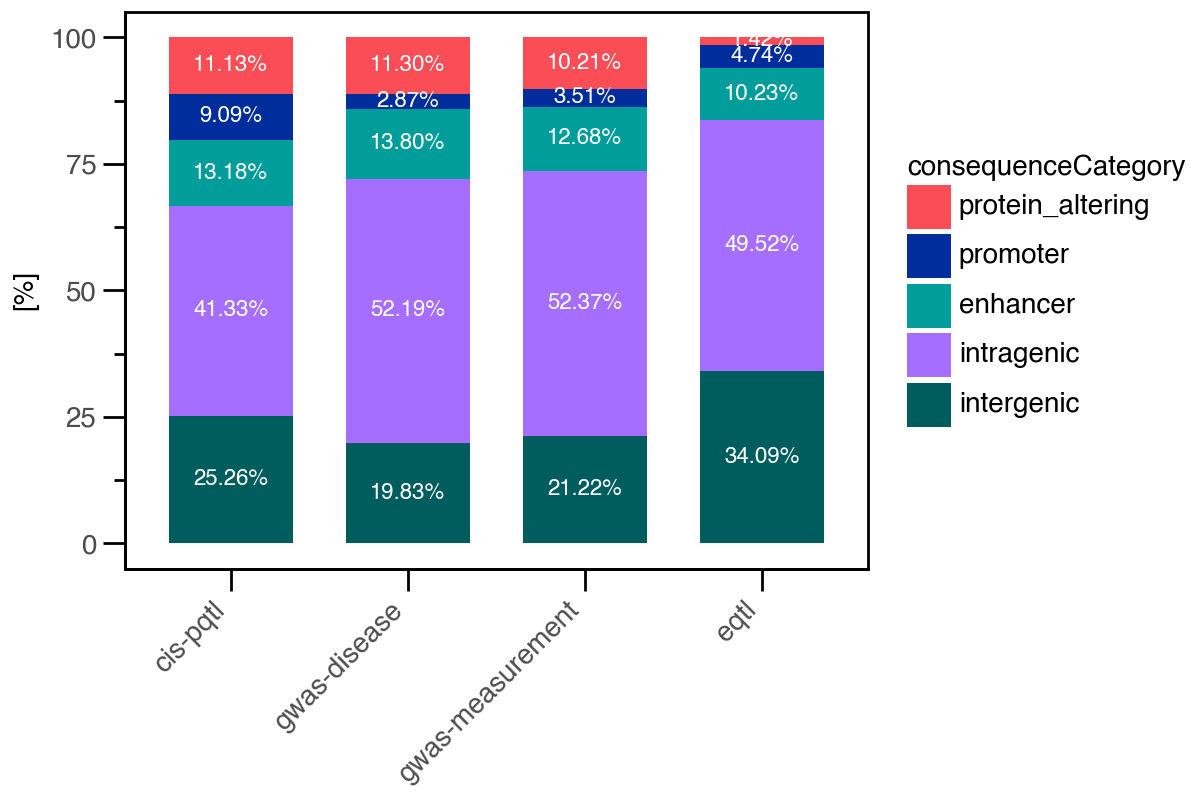

In [29]:
plot = consequence_dataset_percentage.toPandas() >> p9.ggplot() + p9.geom_col(
    p9.aes(
        x="reorder(studyType, nTotal)",
        y="pConsequenceValue",
        fill="reorder(consequenceCategory, ranking)",
        width=0.7,
    )
) + OpenTargetsTheme.categorical_theme(5) + p9.theme(figure_size=(6, 4)) + p9.theme(
    axis_text_y=p9.element_text(rotation=0, hjust=1, size=10),
    axis_text_x=p9.element_text(size=10),
    legend_text=p9.element_text(size=10),
) + p9.labs(x="", y="[%]", fill="consequenceCategory") + p9.theme(
    legend_title=p9.element_text(size=10, weight=50), legend_position="right"
) + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors) + p9.geom_text(
    p9.aes(
        x="reorder(studyType, nTotal)",
        y="pConsequenceValue",
        label="pConsequneceLabel",
        group="reorder(consequenceCategory, ranking)",
    ),
    position=p9.position_stack(vjust=0.5),
    size=8,
    color="white",
)
plot

## GWAS Consequence vs abs beta

Filter the ranked dataset by GWAS studies only and average the max absolute effect per consequence category.
Additionally calculate the standard error and CI for the mean.


In [30]:
w6 = Window.partitionBy("studyType", "consequenceCategory")
w7 = Window.partitionBy("studyType")
gwas_studies = [StudyType.GWAS_DISEASE.value, StudyType.GWAS_MEASUREMENT.value]

beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"
stat_label = f.concat_ws(
    " / ",
    "consequenceCategory",
    f.concat_ws("=", f.lit("N"), "nTotal"),
    f.concat_ws(
        plus_minus,
        f.concat_ws("=", f.lit(beta + hat), f.round("avgMaxAbsEstimatedBeta", 3)),
        f.round(1.96 * f.col("seMaxAbsEstimatedBeta"), 3),
    ),
)


gwas_consequence_vs_beta = (
    consequence_dataset_ranked.filter(f.col("studyType").isin(*gwas_studies))
    .withColumn("nTotal", f.count("variantId").over(w6))
    .withColumn("nConsequence", f.count("variantId").over(w6))
    .withColumn("pConsequenceValue", (f.col("nConsequence") / f.col("nTotal")) * 100)
    .withColumn("pConsequneceLabel", f.concat(f.format_number(f.col("pConsequenceValue"), 2), f.lit("%")))
    .withColumn("avgMaxAbsEstimatedBeta", f.avg("maxAbsEstimatedBeta").over(w6))
    .withColumn("stdMaxAbsEstimatedBeta", f.stddev("maxAbsEstimatedBeta").over(w6))
    .withColumn("seMaxAbsEstimatedBeta", f.col("stdMaxAbsEstimatedBeta") / f.sqrt(f.col("nConsequence")))
    .withColumn("CILower", f.col("avgMaxAbsEstimatedBeta") - 1.96 * f.col("seMaxAbsEstimatedBeta"))
    .withColumn("CIUpper", f.col("avgMaxAbsEstimatedBeta") + 1.96 * f.col("seMaxAbsEstimatedBeta"))
    .withColumn("statisticLabel", stat_label)
    .drop("lowestInRanking", "variantId", "maxAbsEstimatedBeta")
    .drop_duplicates(["studyType", "consequenceCategory"])
    .cache()
)


print(f"GWAS consequence vs max abs beta -  {gwas_consequence_vs_beta.count():,} ")
gwas_consequence_vs_beta.toPandas().head(20)

26/03/09 16:59:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


GWAS consequence vs max abs beta -  10 


,studyType,geneId,distanceFromTss,consequenceCategory,consequenceSource,partition,ranking,con,nTotal,nConsequence,pConsequenceValue,pConsequneceLabel,avgMaxAbsEstimatedBeta,stdMaxAbsEstimatedBeta,seMaxAbsEstimatedBeta,CILower,CIUpper,statisticLabel
0,gwas-disease,ENSG00000165806,-45614,protein_altering,vep,"MONDO_0005129,gwas-disease",1,1,798,798,100.0,100.00%,0.355560,0.424646,0.015032,0.326096,0.385023,protein_altering / N=798 / β̂=0.356±0.029
1,gwas-disease,ENSG00000227128,18488,intergenic,vep,"EFO_0005423,gwas-disease",6,1,1401,1401,100.0,100.00%,0.205025,0.270548,0.007228,0.190858,0.219192,intergenic / N=1401 / β̂=0.205±0.014
2,gwas-disease,ENSG00000227128,114,promoter,interval,"EFO_0005423,gwas-disease",2,1,203,203,100.0,100.00%,0.254236,0.373183,0.026192,0.202899,0.305573,promoter / N=203 / β̂=0.254±0.051
3,gwas-measurement,ENSG00000283232,-9291,intragenic,vep,"EFO_0010934,gwas-measurement",4,2,19190,19190,100.0,100.00%,0.094454,0.186352,0.001345,0.091817,0.097090,intragenic / N=19190 / β̂=0.094±0.003
4,gwas-measurement,ENSG00000303041,92842,intergenic,vep,"OBA_2045267,gwas-measurement",6,1,7776,7776,100.0,100.00%,0.094197,0.183225,0.002078,0.090125,0.098270,intergenic / N=7776 / β̂=0.094±0.004
5,gwas-measurement,ENSG00000095539,-10799,protein_altering,vep,"EFO_0004532,gwas-measurement",1,1,3742,3742,100.0,100.00%,0.212460,0.333652,0.005454,0.201769,0.223150,protein_altering / N=3742 / β̂=0.212±0.011
6,gwas-disease,ENSG00000148842,-151418,enhancer,interval,"EFO_0001645,gwas-disease",3,3,975,975,100.0,100.00%,0.218314,0.286859,0.009187,0.200308,0.236320,enhancer / N=975 / β̂=0.218±0.018
7,gwas-disease,ENSG00000107566,-33592,intragenic,vep,"HP_0001392,gwas-disease",4,1,3687,3687,100.0,100.00%,0.205434,0.271910,0.004478,0.196657,0.214211,intragenic / N=3687 / β̂=0.205±0.009
8,gwas-measurement,ENSG00000107566,-55169,enhancer,interval,"EFO_0010934,gwas-measurement",3,1,4646,4646,100.0,100.00%,0.094853,0.182329,0.002675,0.089610,0.100096,enhancer / N=4646 / β̂=0.095±0.005
9,gwas-measurement,ENSG00000138107,-413,promoter,interval,"EFO_0004305,gwas-measurement",2,1,1287,1287,100.0,100.00%,0.171237,0.347107,0.009676,0.152274,0.190201,promoter / N=1287 / β̂=0.171±0.019


In [31]:
Path(mean_absolute_effect_by_consequence_path).parent.mkdir(parents=True, exist_ok=True)
gwas_consequence_vs_beta.toPandas().to_csv(mean_absolute_effect_by_consequence_path, index=False)

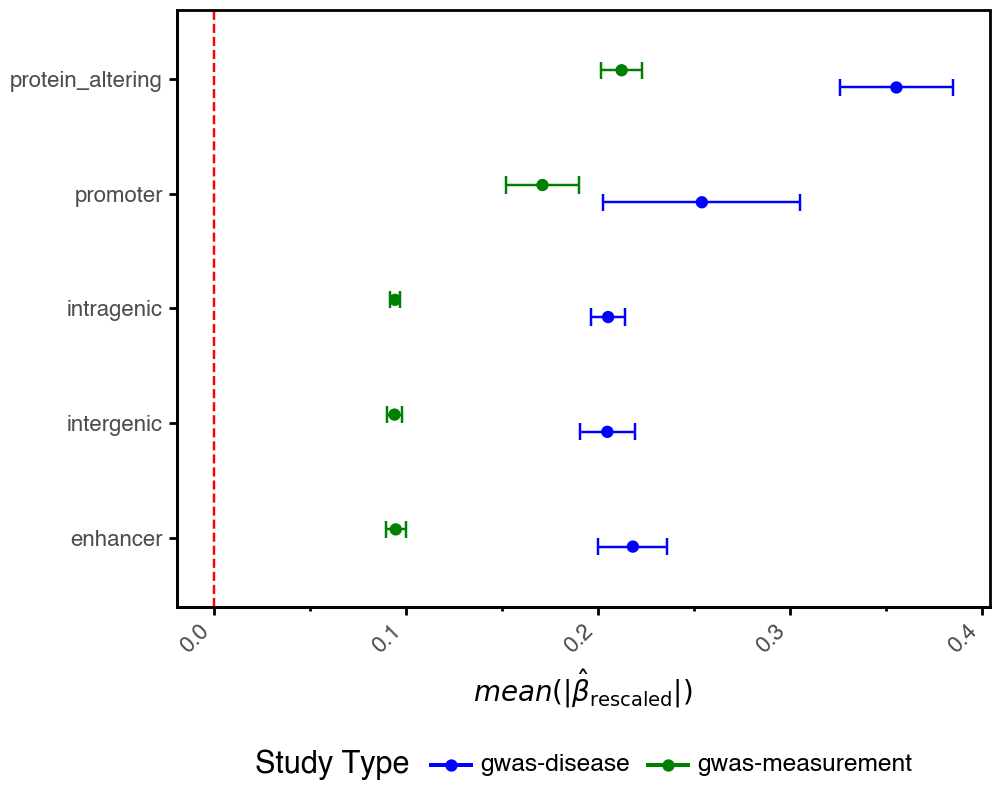

In [32]:
combined_plot = (
    gwas_consequence_vs_beta.toPandas()
    >> p9.ggplot()
    + p9.geom_point(
        p9.aes(x="consequenceCategory", y="avgMaxAbsEstimatedBeta", color="studyType"),
        size=1.5,
        position=p9.position_dodge(width=0.3),
    )
    + p9.geom_errorbar(
        p9.aes(x="consequenceCategory", ymin="CILower", ymax="CIUpper", color="studyType"),
        width=0.3,
        position=p9.position_dodge(width=0.3),
    )
    + p9.scale_color_manual(values={"gwas-measurement": "green", "gwas-disease": "blue"}, name="Study Type")
    + OpenTargetsTheme.theme
    + p9.theme(axis_text_y=p9.element_text(rotation=0))
    + p9.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + p9.theme(legend_position="bottom", figure_size=(5, 4))
    + p9.geom_hline(p9.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + p9.coord_flip()
)
combined_plot

## molQTL Consequence vs abs beta


In [35]:
w6 = Window.partitionBy("studyType", "consequenceCategory")
w7 = Window.partitionBy("studyType")
gwas_studies = [StudyType.EQTL.value, StudyType.CIS_PQTL.value]

beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"
stat_label = f.concat_ws(
    " / ",
    "consequenceCategory",
    f.concat_ws("=", f.lit("N"), "nTotal"),
    f.concat_ws(
        plus_minus,
        f.concat_ws("=", f.lit(beta + hat), f.round("avgMaxAbsEstimatedBeta", 3)),
        f.round(1.96 * f.col("seMaxAbsEstimatedBeta"), 3),
    ),
)


gwas_consequence_vs_beta = (
    consequence_dataset_ranked.filter(f.col("studyType").isin(*gwas_studies))
    .withColumn("nTotal", f.count("variantId").over(w6))
    .withColumn("nConsequence", f.count("variantId").over(w6))
    .withColumn("pConsequenceValue", (f.col("nConsequence") / f.col("nTotal")) * 100)
    .withColumn("pConsequneceLabel", f.concat(f.format_number(f.col("pConsequenceValue"), 2), f.lit("%")))
    .withColumn("avgMaxAbsEstimatedBeta", f.avg("maxAbsEstimatedBeta").over(w6))
    .withColumn("stdMaxAbsEstimatedBeta", f.stddev("maxAbsEstimatedBeta").over(w6))
    .withColumn("seMaxAbsEstimatedBeta", f.col("stdMaxAbsEstimatedBeta") / f.sqrt(f.col("nConsequence")))
    .withColumn("CILower", f.col("avgMaxAbsEstimatedBeta") - 1.96 * f.col("seMaxAbsEstimatedBeta"))
    .withColumn("CIUpper", f.col("avgMaxAbsEstimatedBeta") + 1.96 * f.col("seMaxAbsEstimatedBeta"))
    .withColumn("statisticLabel", stat_label)
    .drop("lowestInRanking", "variantId", "maxAbsEstimatedBeta")
    .drop_duplicates(["studyType", "consequenceCategory"])
    .cache()
)


print(f"GWAS consequence vs max abs beta -  {gwas_consequence_vs_beta.count():,} ")
gwas_consequence_vs_beta.toPandas().head(20)

GWAS consequence vs max abs beta -  10 


,studyType,geneId,distanceFromTss,consequenceCategory,consequenceSource,partition,ranking,con,nTotal,nConsequence,pConsequenceValue,pConsequneceLabel,avgMaxAbsEstimatedBeta,stdMaxAbsEstimatedBeta,seMaxAbsEstimatedBeta,CILower,CIUpper,statisticLabel
0,eqtl,ENSG00000095485,-2112,enhancer,interval,"ENSG00000196072,eqtl",3,1,13050,13050,100.0,100.00%,1.000915,0.466233,0.004081,0.992916,1.008915,enhancer / N=13050 / β̂=1.001±0.008
1,cis-pqtl,ENSG00000138175,-107,intragenic,vep,"ENSG00000138175,cis-pqtl",4,3,787,787,100.0,100.00%,0.370050,0.282863,0.010083,0.350288,0.389813,intragenic / N=787 / β̂=0.37±0.02
2,cis-pqtl,ENSG00000305032,82180,intergenic,vep,"ENSG00000107554,cis-pqtl",6,2,481,481,100.0,100.00%,0.392021,0.288804,0.013168,0.366211,0.417831,intergenic / N=481 / β̂=0.392±0.026
3,cis-pqtl,ENSG00000121898,22224,enhancer,interval,"ENSG00000121898,cis-pqtl",3,1,251,251,100.0,100.00%,0.353456,0.259932,0.016407,0.321299,0.385613,enhancer / N=251 / β̂=0.353±0.032
4,eqtl,ENSG00000120055,-565,protein_altering,vep,"ENSG00000269609,eqtl",1,1,1816,1816,100.0,100.00%,1.159448,0.566094,0.013284,1.133411,1.185484,protein_altering / N=1816 / β̂=1.159±0.026
5,eqtl,ENSG00000305032,82819,intergenic,vep,"ENSG00000107554,eqtl",6,3,43500,43500,100.0,100.00%,0.989181,0.466421,0.002236,0.984798,0.993564,intergenic / N=43500 / β̂=0.989±0.004
6,eqtl,ENSG00000107554,34,promoter,interval,"ENSG00000107554,eqtl",2,1,6045,6045,100.0,100.00%,1.110800,0.517334,0.006654,1.097759,1.123842,promoter / N=6045 / β̂=1.111±0.013
7,cis-pqtl,ENSG00000148377,-6089,protein_altering,vep,"ENSG00000148377,cis-pqtl",1,2,212,212,100.0,100.00%,0.564362,0.395135,0.027138,0.511171,0.617552,protein_altering / N=212 / β̂=0.564±0.053
8,eqtl,ENSG00000120054,-16466,intragenic,vep,"ENSG00000120054,eqtl",4,2,63175,63175,100.0,100.00%,0.998511,0.470465,0.001872,0.994843,1.002180,intragenic / N=63175 / β̂=0.999±0.004
9,cis-pqtl,ENSG00000138175,-105,promoter,interval,"ENSG00000138175,cis-pqtl",2,1,173,173,100.0,100.00%,0.390269,0.274524,0.020872,0.349360,0.431177,promoter / N=173 / β̂=0.39±0.041


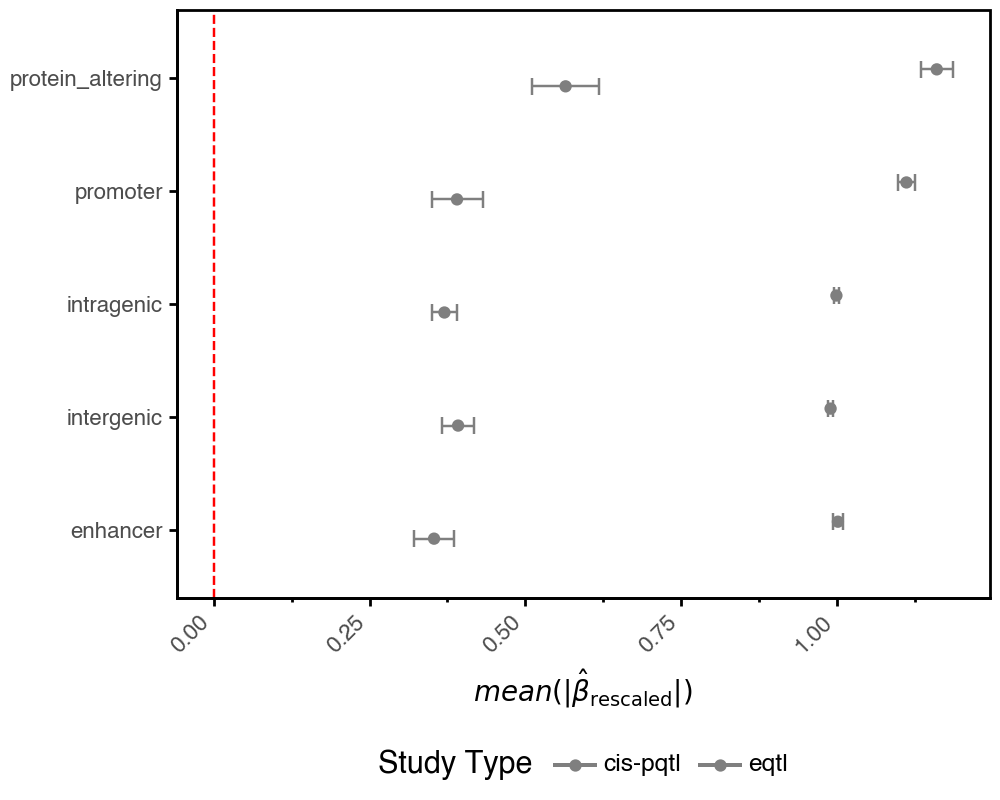

In [36]:
combined_plot = (
    gwas_consequence_vs_beta.toPandas()
    >> p9.ggplot()
    + p9.geom_point(
        p9.aes(x="consequenceCategory", y="avgMaxAbsEstimatedBeta", color="studyType"),
        size=1.5,
        position=p9.position_dodge(width=0.3),
    )
    + p9.geom_errorbar(
        p9.aes(x="consequenceCategory", ymin="CILower", ymax="CIUpper", color="studyType"),
        width=0.3,
        position=p9.position_dodge(width=0.3),
    )
    + p9.scale_color_manual(values={"gwas-measurement": "green", "gwas-disease": "blue"}, name="Study Type")
    + OpenTargetsTheme.theme
    + p9.theme(axis_text_y=p9.element_text(rotation=0))
    + p9.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + p9.theme(legend_position="bottom", figure_size=(5, 4))
    + p9.geom_hline(p9.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + p9.coord_flip()
)
combined_plot

In [ ]:
session.spark.stop()